In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.35, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

SESSION   = '../data/latest2.parquet'
FEE_BPS   = 10 / 10_000
QUOTE_SZ  = 0.005
MAX_INV   = 0.10
FILL_K    = 10_000

df = pd.read_parquet(SESSION)
df['ts'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.set_index('ts').sort_index()

# derived columns used throughout
df['inv_delta']   = df['inventory'].diff().fillna(0)
df['fill_mask']   = df['inv_delta'].abs() > 1e-9
df['fill_side']   = np.where(df['inv_delta'] > 1e-9, 'buy',
                    np.where(df['inv_delta'] < -1e-9, 'sell', 'none'))
df['mid_ret']     = df['mid'].pct_change().fillna(0)
df['quote_dist_bid'] = df['mid'] - df['quote_bid']
df['quote_dist_ask'] = df['quote_ask'] - df['mid']
df['realized_vol']   = df['mid_ret'].rolling(30).std()

duration_s = (df.index[-1] - df.index[0]).total_seconds()
n_fills    = df['fill_mask'].sum()
n_orders   = len(df) * 2

print(f'Session  : {df.index[0]}  →  {df.index[-1]}')
print(f'Duration : {duration_s/60:.1f} min  |  {len(df)} rows  |  {n_fills} fills')

Session  : 2026-05-14 09:03:43.016000  →  2026-05-14 09:09:42.945000
Duration : 6.0 min  |  360 rows  |  158 fills


# 1 · Data sanity check

Prove inputs are consistent before touching any analysis.

=== Sanity checks ===
  Timestamps monotonic        : True  ✓
  Max gap (s)                 : 1.10
  Negative spread rows        : 0
  Mid price spikes (>4σ)      : 0
  Missing rows (NaN mid)      : 0
  Spread mean ($)             : 0.010
  Spread std ($)              : 0.000


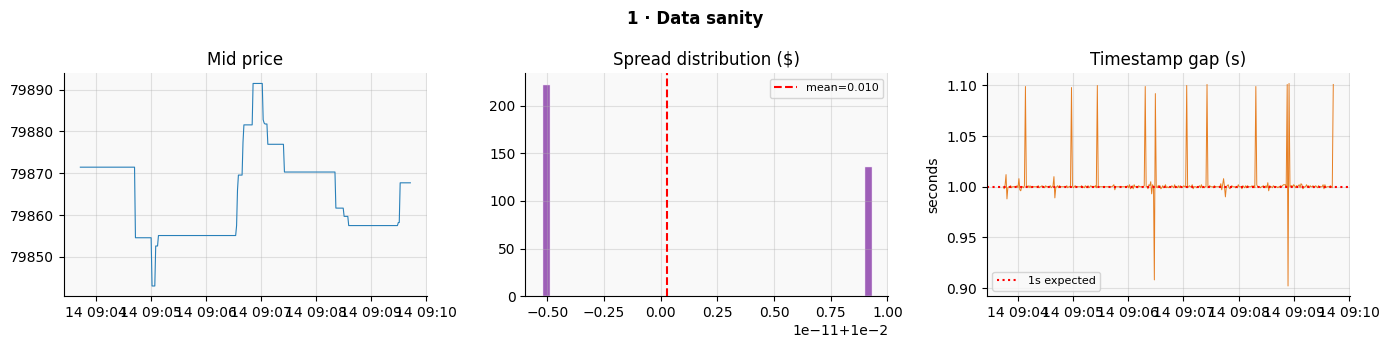

In [32]:
ts_gaps = df['timestamp'].diff().dropna()
spread   = df['ask_0_price'] - df['bid_0_price']
mid_z    = (df['mid'] - df['mid'].mean()) / df['mid'].std()

checks = {
    'Timestamps monotonic'  : bool(df['timestamp'].is_monotonic_increasing),
    'Max gap (s)'           : f"{ts_gaps.max()/1000:.2f}",
    'Negative spread rows'  : int((spread <= 0).sum()),
    'Mid price spikes (>4σ)': int((mid_z.abs() > 4).sum()),
    'Missing rows (NaN mid)': int(df['mid'].isna().sum()),
    'Spread mean ($)'       : f"{spread.mean():.3f}",
    'Spread std ($)'        : f"{spread.std():.3f}",
}
print('=== Sanity checks ===')
for k, v in checks.items():
    flag = '  ✓' if v not in [False, True] or v else '  ✗ FAIL'
    print(f'  {k:<28}: {v}{flag if isinstance(v, bool) else ""}')

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(df.index, df['mid'], linewidth=0.8, color='#2980b9')
axes[0].set_title('Mid price')

axes[1].hist(spread, bins=40, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].axvline(spread.mean(), color='red', linestyle='--', label=f'mean={spread.mean():.3f}')
axes[1].set_title('Spread distribution ($)')
axes[1].legend(fontsize=8)

axes[2].plot(df.index[1:], ts_gaps / 1000, linewidth=0.7, color='#e67e22')
axes[2].axhline(1.0, color='red', linestyle=':', label='1s expected')
axes[2].set_title('Timestamp gap (s)')
axes[2].set_ylabel('seconds')
axes[2].legend(fontsize=8)

plt.suptitle('1 · Data sanity', fontweight='bold')
plt.tight_layout()
plt.show()

# 2 · Feature validation

Signals must be stationary and well-behaved before trading them.

=== Feature stationarity (mean should ≈ 0) ===
  OB Imbalance      : mean=+0.0278  std=0.5912  skew=-0.177  range=[-0.997, 0.997]
  Trade Flow Imb    : mean=+0.1517  std=0.6570  skew=-0.313  range=[-1.000, 1.000]
  Alpha             : mean=+0.0838  std=0.4610  skew=-0.106  range=[-0.873, 0.949]


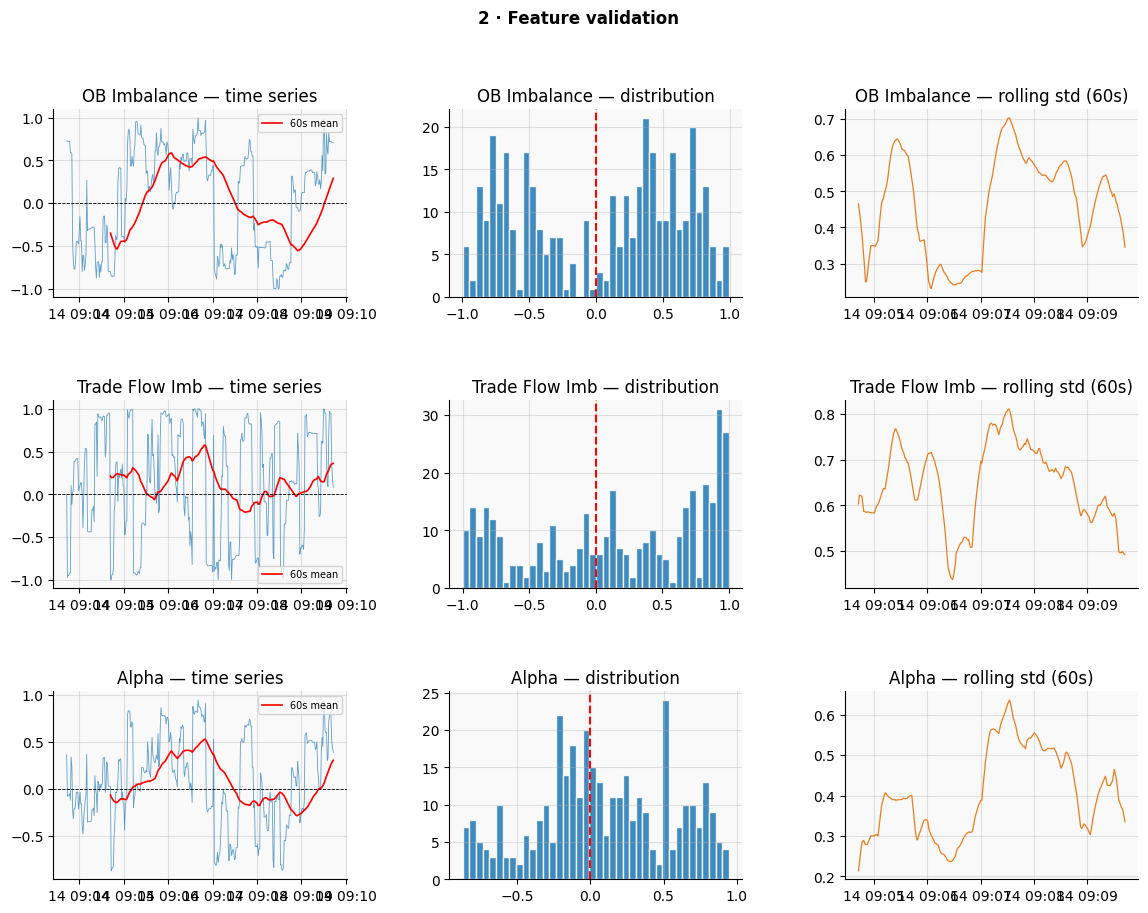

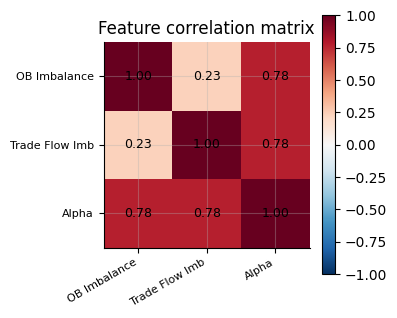

In [33]:
features = ['obi', 'tfi', 'alpha']
feat_labels = {'obi': 'OB Imbalance', 'tfi': 'Trade Flow Imb', 'alpha': 'Alpha'}

# stationarity: ADF test
from scipy.stats import pearsonr
print('=== Feature stationarity (mean should ≈ 0) ===')
for f in features:
    s = df[f].dropna()
    print(f'  {feat_labels[f]:<18}: mean={s.mean():+.4f}  std={s.std():.4f}  '
          f'skew={s.skew():.3f}  range=[{s.min():.3f}, {s.max():.3f}]')

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

for row, f in enumerate(features):
    s = df[f]

    # time series + rolling mean
    ax = fig.add_subplot(gs[row, 0])
    ax.plot(df.index, s, linewidth=0.6, alpha=0.7)
    ax.plot(df.index, s.rolling(60).mean(), color='red', linewidth=1.2, label='60s mean')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f'{feat_labels[f]} — time series')
    ax.legend(fontsize=7)

    # distribution
    ax = fig.add_subplot(gs[row, 1])
    ax.hist(s.dropna(), bins=40, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'{feat_labels[f]} — distribution')

    # rolling std (stability)
    ax = fig.add_subplot(gs[row, 2])
    ax.plot(df.index, s.rolling(60).std(), color='#e67e22', linewidth=0.9)
    ax.set_title(f'{feat_labels[f]} — rolling std (60s)')

plt.suptitle('2 · Feature validation', fontweight='bold')
plt.savefig('feature_validation.png', dpi=120, bbox_inches='tight')
plt.show()

# correlation matrix
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels([feat_labels[f] for f in features], rotation=30, ha='right', fontsize=8)
ax.set_yticklabels([feat_labels[f] for f in features], fontsize=8)
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

Ask crosses book : 39.4% of time
Bid crosses book : 53.6% of time


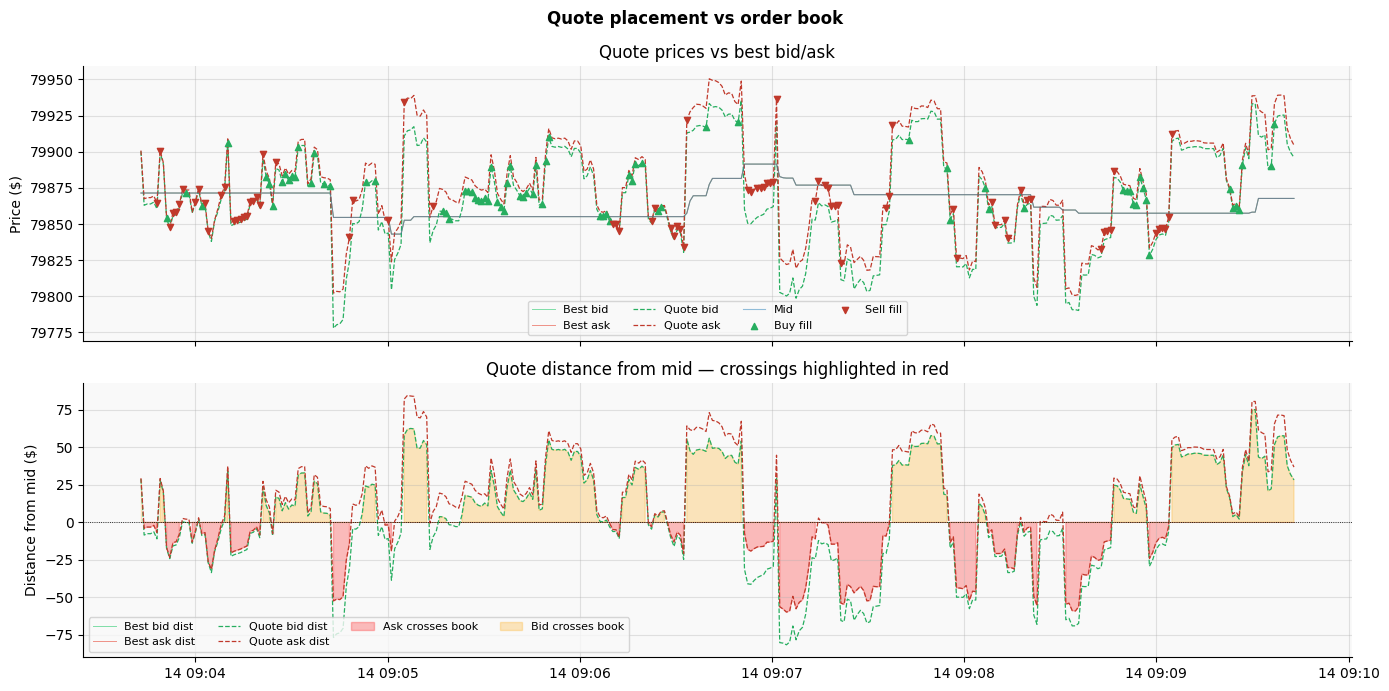

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- price level view ---
ax = axes[0]
ax.plot(df.index, df['bid_0_price'], color='#2ecc71', linewidth=0.7, alpha=0.6, label='Best bid')
ax.plot(df.index, df['ask_0_price'], color='#e74c3c', linewidth=0.7, alpha=0.6, label='Best ask')
ax.plot(df.index, df['quote_bid'],   color='#27ae60', linewidth=0.9, linestyle='--', label='Quote bid')
ax.plot(df.index, df['quote_ask'],   color='#c0392b', linewidth=0.9, linestyle='--', label='Quote ask')
ax.plot(df.index, df['mid'],         color='#2980b9', linewidth=0.8, alpha=0.5, label='Mid')

# mark fills
buy_fills  = df[df['fill_side'] == 'buy']
sell_fills = df[df['fill_side'] == 'sell']
ax.scatter(buy_fills.index,  buy_fills['quote_bid'],  color='#27ae60', s=20, zorder=5, marker='^', label='Buy fill')
ax.scatter(sell_fills.index, sell_fills['quote_ask'], color='#c0392b', s=20, zorder=5, marker='v', label='Sell fill')

ax.set_title('Quote prices vs best bid/ask')
ax.set_ylabel('Price ($)')
ax.legend(fontsize=8, ncol=4)

# --- distance from mid ---
ax = axes[1]
ax.plot(df.index, df['bid_0_price'] - df['mid'], color='#2ecc71', linewidth=0.7, alpha=0.6, label='Best bid dist')
ax.plot(df.index, df['ask_0_price'] - df['mid'], color='#e74c3c', linewidth=0.7, alpha=0.6, label='Best ask dist')
ax.plot(df.index, df['quote_bid']   - df['mid'], color='#27ae60', linewidth=0.9, linestyle='--', label='Quote bid dist')
ax.plot(df.index, df['quote_ask']   - df['mid'], color='#c0392b', linewidth=0.9, linestyle='--', label='Quote ask dist')
ax.axhline(0, color='black', linewidth=0.6, linestyle=':')

# shade regions where quote crosses the book
ax.fill_between(df.index,
    df['quote_ask'] - df['mid'], df['bid_0_price'] - df['mid'],
    where=(df['quote_ask'] < df['bid_0_price']),
    color='red', alpha=0.25, label='Ask crosses book')
ax.fill_between(df.index,
    df['ask_0_price'] - df['mid'], df['quote_bid'] - df['mid'],
    where=(df['quote_bid'] > df['ask_0_price']),
    color='orange', alpha=0.25, label='Bid crosses book')

ax.set_title('Quote distance from mid — crossings highlighted in red')
ax.set_ylabel('Distance from mid ($)')
ax.legend(fontsize=8, ncol=4)

pct_ask_crossed = (df['quote_ask'] < df['bid_0_price']).mean()
pct_bid_crossed = (df['quote_bid'] > df['ask_0_price']).mean()
print(f'Ask crosses book : {pct_ask_crossed:.1%} of time')
print(f'Bid crosses book : {pct_bid_crossed:.1%} of time')

plt.suptitle('Quote placement vs order book', fontweight='bold')
plt.tight_layout()
plt.show()

# 3 · Predictive power

Does alpha actually predict future returns? If not, everything else is noise.

=== Alpha predictiveness (IC = correlation with future return) ===
  horizon=1s   : IC=+0.1676  p=0.0014  ✓ significant
  horizon=5s   : IC=+0.2659  p=0.0000  ✓ significant
  horizon=10s  : IC=+0.2773  p=0.0000  ✓ significant
  horizon=30s  : IC=+0.2689  p=0.0000  ✓ significant


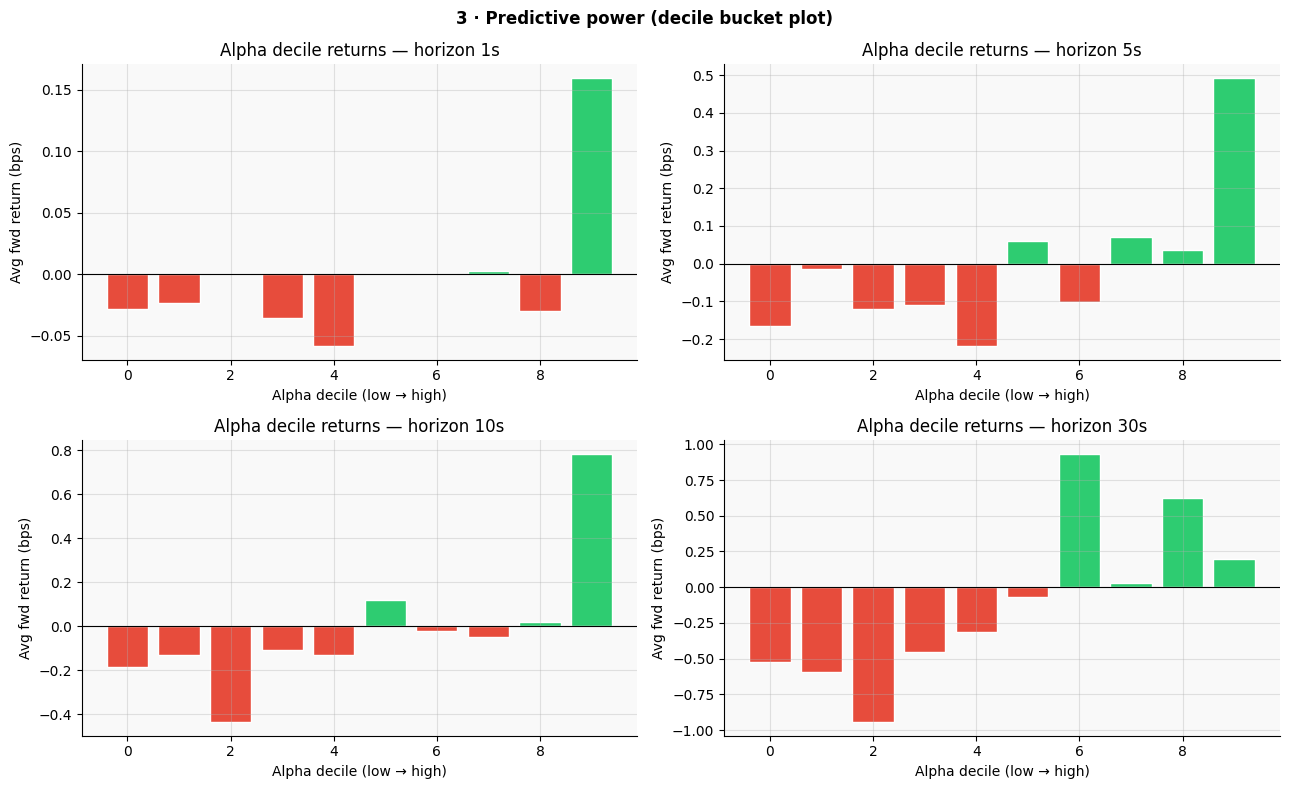

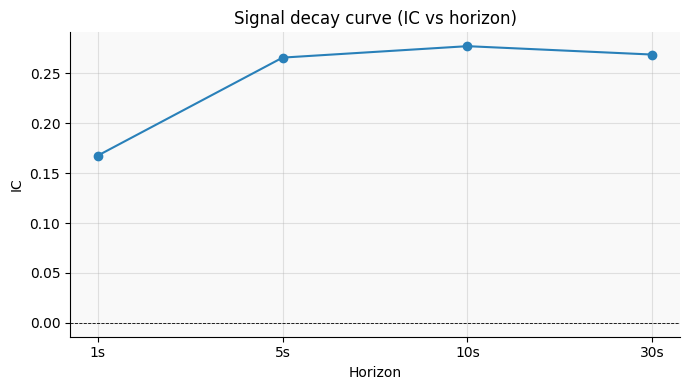

In [35]:
horizons = {'1s': 1, '5s': 5, '10s': 10, '30s': 30}

# future returns at each horizon
for label, h in horizons.items():
    df[f'fwd_ret_{label}'] = df['mid'].pct_change(h).shift(-h)

print('=== Alpha predictiveness (IC = correlation with future return) ===')
for label in horizons:
    valid = df[['alpha', f'fwd_ret_{label}']].dropna()
    ic, pval = pearsonr(valid['alpha'], valid[f'fwd_ret_{label}'])
    print(f'  horizon={label:<5}: IC={ic:+.4f}  p={pval:.4f}  {"✓ significant" if pval < 0.05 else "✗ not significant"}')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for idx, (label, h) in enumerate(horizons.items()):
    valid = df[['alpha', f'fwd_ret_{label}']].dropna()
    ax = axes[idx]

    # decile bucket plot
    valid = valid.copy()
    valid['decile'] = pd.qcut(valid['alpha'], 10, labels=False, duplicates='drop')
    bucket_means = valid.groupby('decile')[f'fwd_ret_{label}'].mean()
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in bucket_means]
    ax.bar(bucket_means.index, bucket_means.values * 10000, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Alpha decile (low → high)')
    ax.set_ylabel('Avg fwd return (bps)')
    ax.set_title(f'Alpha decile returns — horizon {label}')

plt.suptitle('3 · Predictive power (decile bucket plot)', fontweight='bold')
plt.tight_layout()
plt.show()

# signal decay curve
fig, ax = plt.subplots(figsize=(7, 4))
ics = []
for label in horizons:
    valid = df[['alpha', f'fwd_ret_{label}']].dropna()
    ic, _ = pearsonr(valid['alpha'], valid[f'fwd_ret_{label}'])
    ics.append(ic)
ax.plot(list(horizons.keys()), ics, marker='o', linewidth=1.5, color='#2980b9')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('Signal decay curve (IC vs horizon)')
ax.set_xlabel('Horizon')
ax.set_ylabel('IC')
plt.tight_layout()
plt.show()

# 4 · Volatility model validation

Spread should widen when vol is high.

Vol prediction error (EWMA_10s vs realized_10s):
  MAE  : 0.000008
  Bias : +0.000001


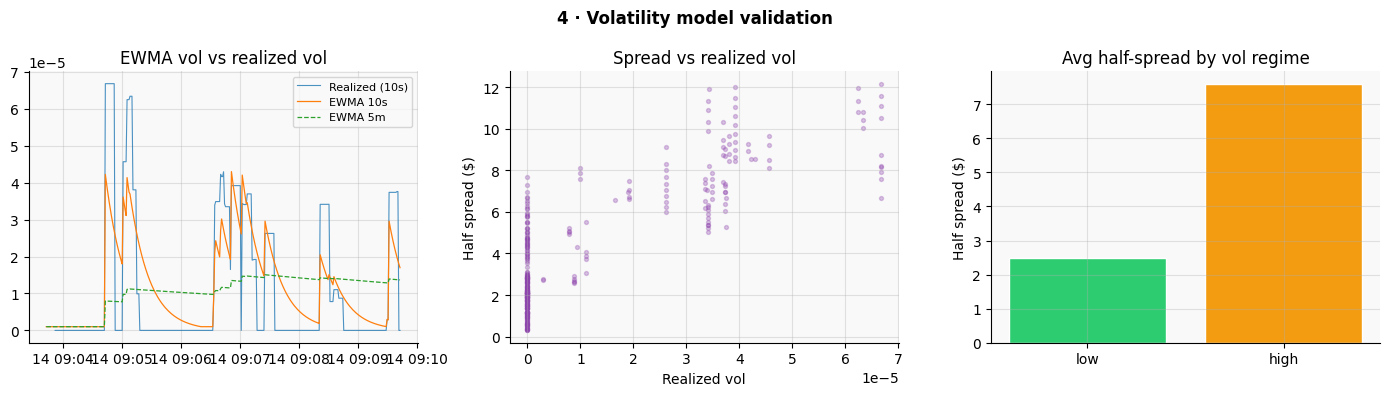

In [36]:
realized  = df['mid_ret'].rolling(10).std()    # 10s realized
ewma_fast = df['vol_10s']
ewma_slow = df['vol_5m']

vol_err = (ewma_fast - realized).dropna()
print(f'Vol prediction error (EWMA_10s vs realized_10s):')
print(f'  MAE  : {vol_err.abs().mean():.6f}')
print(f'  Bias : {vol_err.mean():+.6f}')

# vol regime labels
vol_q = realized.quantile([0.33, 0.67])
df['vol_regime'] = pd.cut(realized, bins=[-np.inf, vol_q.iloc[0], vol_q.iloc[1], np.inf],
                          labels=['low', 'med', 'high'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(df.index, realized,  label='Realized (10s)', linewidth=0.8, alpha=0.8)
axes[0].plot(df.index, ewma_fast, label='EWMA 10s',       linewidth=0.9)
axes[0].plot(df.index, ewma_slow, label='EWMA 5m',        linewidth=0.9, linestyle='--')
axes[0].set_title('EWMA vol vs realized vol')
axes[0].legend(fontsize=8)

axes[1].scatter(realized.dropna(), df['half_spread'].loc[realized.dropna().index],
                alpha=0.3, s=8, color='#8e44ad')
axes[1].set_xlabel('Realized vol')
axes[1].set_ylabel('Half spread ($)')
axes[1].set_title('Spread vs realized vol')

regime_spread = df.groupby('vol_regime', observed=True)['half_spread'].mean()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[2].bar(regime_spread.index, regime_spread.values, color=colors, edgecolor='white')
axes[2].set_title('Avg half-spread by vol regime')
axes[2].set_ylabel('Half spread ($)')

plt.suptitle('4 · Volatility model validation', fontweight='bold')
plt.tight_layout()
plt.show()

# 5 · Execution model — fill realism

Do tighter quotes actually fill more?

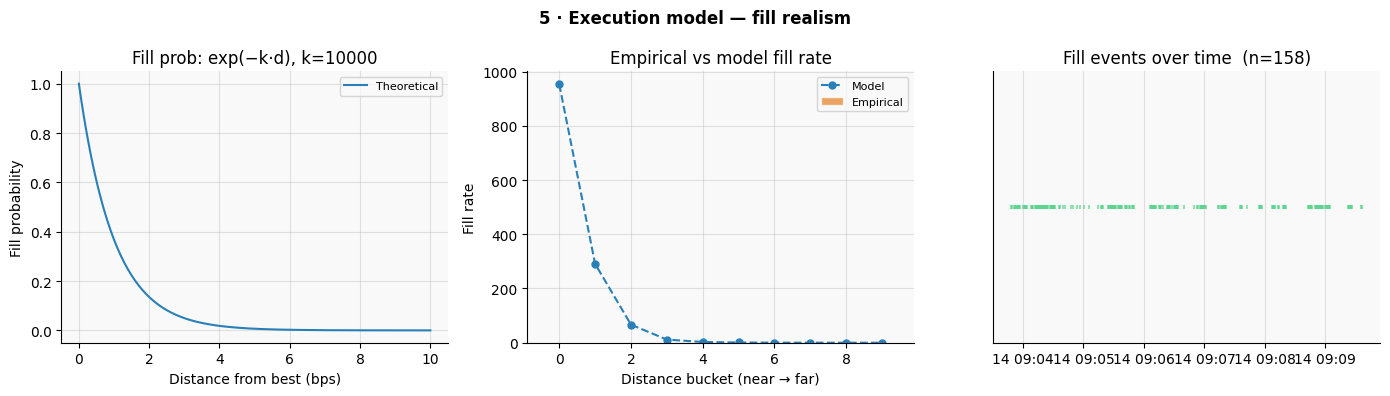

Fill rate: 0.2194  (158 fills / 720 orders)


In [37]:
import math

# theoretical fill probability curve
distances = np.linspace(0, 0.0010, 300)      # 0 → 10bps
p_theory  = np.exp(-FILL_K * distances)

# empirical: did rows where quote was tighter actually fill more?
df['dist_bid_pct'] = df['quote_dist_bid'] / df['mid']
df['dist_ask_pct'] = df['quote_dist_ask'] / df['mid']

# bucket quotes by distance and compute empirical fill rate
n_buckets = 10
df['dist_bucket'] = pd.qcut(df['dist_bid_pct'], n_buckets, labels=False, duplicates='drop')
emp_fill = df.groupby('dist_bucket', observed=True).apply(
    lambda g: g['fill_mask'].sum() / max(len(g), 1)
).reset_index(name='fill_rate')
bucket_centers = df.groupby('dist_bucket', observed=True)['dist_bid_pct'].mean().values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# theoretical curve
axes[0].plot(distances * 10000, p_theory, linewidth=1.5, color='#2980b9', label='Theoretical')
axes[0].set_xlabel('Distance from best (bps)')
axes[0].set_ylabel('Fill probability')
axes[0].set_title(f'Fill prob: exp(−k·d), k={FILL_K}')
axes[0].legend(fontsize=8)

# empirical vs simulated
if len(emp_fill) > 0 and len(bucket_centers) > 0:
    sim_p = np.exp(-FILL_K * bucket_centers)
    axes[1].bar(range(len(emp_fill)), emp_fill['fill_rate'],
                alpha=0.7, label='Empirical', color='#e67e22', edgecolor='white')
    axes[1].plot(range(len(sim_p)), sim_p, 'o--', color='#2980b9', label='Model', markersize=5)
    axes[1].set_xlabel('Distance bucket (near → far)')
    axes[1].set_ylabel('Fill rate')
    axes[1].set_title('Empirical vs model fill rate')
    axes[1].legend(fontsize=8)

# fills over time
fill_times = df.index[df['fill_mask']]
axes[2].scatter(fill_times, [1]*len(fill_times), s=8, alpha=0.5, color='#2ecc71', marker='|')
axes[2].set_title(f'Fill events over time  (n={len(fill_times)})')
axes[2].set_yticks([])

plt.suptitle('5 · Execution model — fill realism', fontweight='bold')
plt.tight_layout()
plt.show()

fill_rate = n_fills / n_orders
print(f'Fill rate: {fill_rate:.4f}  ({n_fills} fills / {n_orders} orders)')

# 6 · Markout / adverse selection

Positive realized spread must survive after markouts. This is the edge test.

=== Markout analysis (positive = edge survived) ===
  1s   : mean=-9.0675  std=19.2152  positive=18.4%
  5s   : mean=-9.1439  std=19.0859  positive=19.0%
  10s  : mean=-8.3162  std=19.3999  positive=25.0%
  30s  : mean=-8.2988  std=22.6243  positive=30.5%


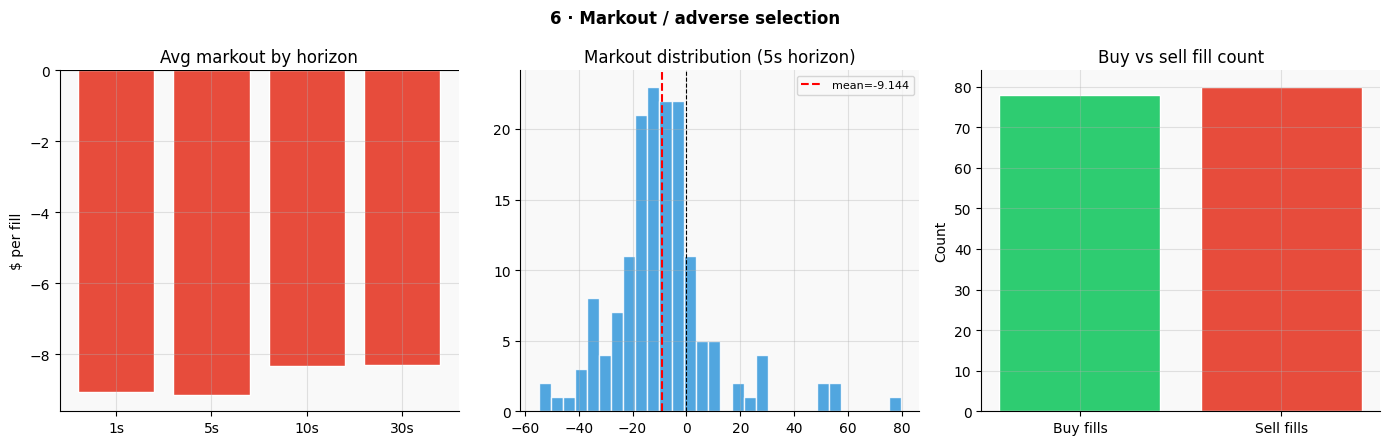

In [38]:
fill_rows = df[df['fill_mask']].copy()
fill_dirs = np.sign(fill_rows['inv_delta'])    # +1 buy, -1 sell

markout_horizons = [1, 5, 10, 30]
markout_results  = {}

for h in markout_horizons:
    markouts = []
    for idx, row in fill_rows.iterrows():
        pos = df.index.get_loc(idx)
        if pos + h < len(df):
            future_mid = df['mid'].iloc[pos + h]
            direction  = np.sign(row['inv_delta'])
            fill_price = row['quote_bid'] if direction > 0 else row['quote_ask']
            markout    = direction * (future_mid - fill_price)
            markouts.append(markout)
    markout_results[f'{h}s'] = np.array(markouts)

print('=== Markout analysis (positive = edge survived) ===')
for label, mo in markout_results.items():
    if len(mo) > 0:
        print(f'  {label:<5}: mean={np.mean(mo):+.4f}  std={np.std(mo):.4f}  '
              f'positive={np.mean(mo>0):.1%}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# markout decay curve
means = [np.mean(v) if len(v) > 0 else 0 for v in markout_results.values()]
axes[0].bar(list(markout_results.keys()), means,
            color=['#2ecc71' if v >= 0 else '#e74c3c' for v in means], edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Avg markout by horizon')
axes[0].set_ylabel('$ per fill')

# markout distribution at 5s
mo5 = markout_results.get('5s', np.array([]))
if len(mo5) > 1:
    axes[1].hist(mo5, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].axvline(np.mean(mo5), color='red', linestyle='--',
                    label=f'mean={np.mean(mo5):.3f}')
    axes[1].set_title('Markout distribution (5s horizon)')
    axes[1].legend(fontsize=8)

# buy vs sell asymmetry
if len(fill_rows) > 0:
    buy_fills  = fill_rows[fill_rows['fill_side'] == 'buy']
    sell_fills = fill_rows[fill_rows['fill_side'] == 'sell']
    axes[2].bar(['Buy fills', 'Sell fills'],
                [len(buy_fills), len(sell_fills)],
                color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[2].set_title('Buy vs sell fill count')
    axes[2].set_ylabel('Count')

plt.suptitle('6 · Markout / adverse selection', fontweight='bold')
plt.tight_layout()
plt.show()

# 7 · Inventory dynamics

If inventory drifts, skewing is wrong.

  Inventory std       : 0.04872 BTC
  Max utilization     : 100.0%
  Time at max inv     : 1.7%
  Zero crossings      : 0


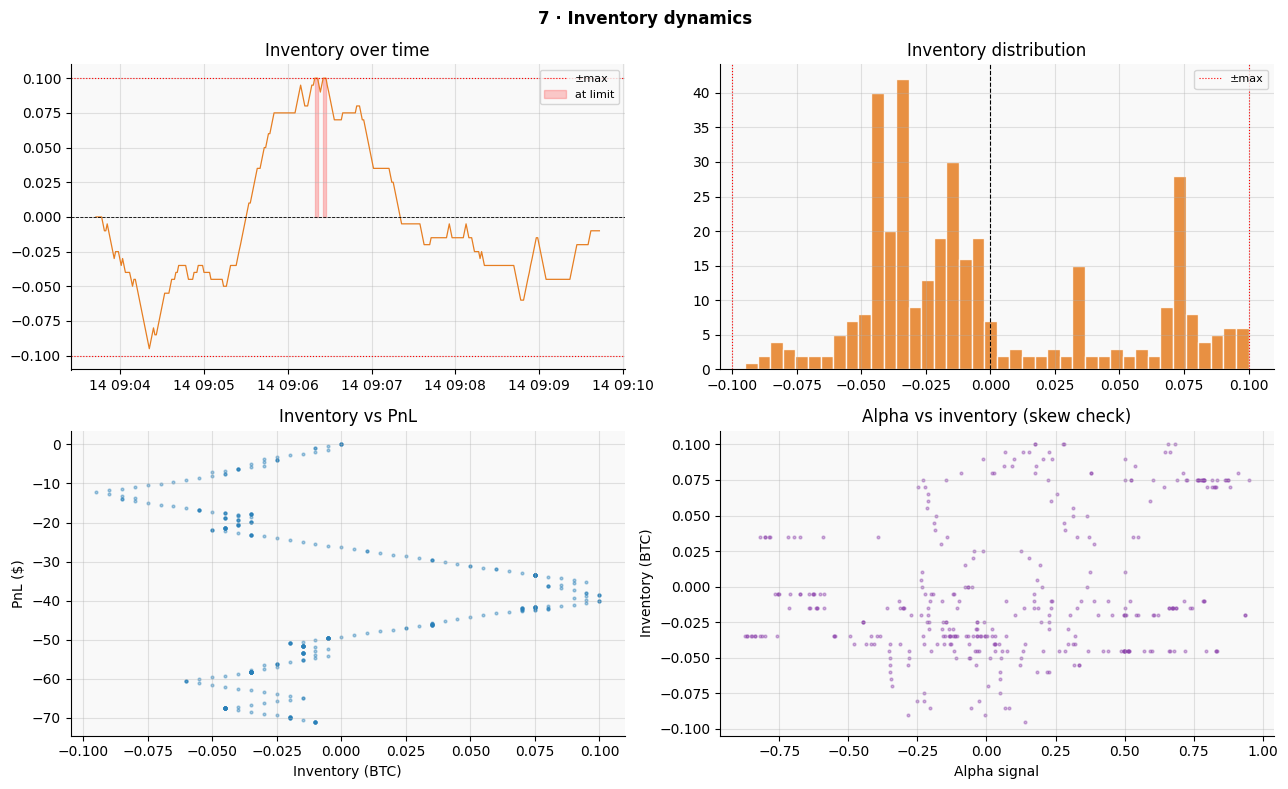

In [39]:
inv = df['inventory'].values
pnl = df['pnl'].values

time_at_max  = float((np.abs(inv) >= MAX_INV).mean())
sign_changes = int(((np.sign(inv[1:]) * np.sign(inv[:-1])) < 0).sum())
inv_std      = float(np.std(inv))
max_util     = float(np.abs(inv).max() / MAX_INV)

print(f'  Inventory std       : {inv_std:.5f} BTC')
print(f'  Max utilization     : {max_util:.1%}')
print(f'  Time at max inv     : {time_at_max:.1%}')
print(f'  Zero crossings      : {sign_changes}')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# inventory time series
ax = axes[0, 0]
ax.plot(df.index, inv, color='#e67e22', linewidth=0.9)
ax.axhline(0,        color='black', linewidth=0.6, linestyle='--')
ax.axhline( MAX_INV, color='red',   linewidth=0.8, linestyle=':', label='±max')
ax.axhline(-MAX_INV, color='red',   linewidth=0.8, linestyle=':')
ax.fill_between(df.index, inv, 0, where=(np.abs(inv) >= MAX_INV),
                color='red', alpha=0.2, label='at limit')
ax.set_title('Inventory over time')
ax.legend(fontsize=8)

# histogram
ax = axes[0, 1]
ax.hist(inv, bins=40, color='#e67e22', edgecolor='white', alpha=0.85)
ax.axvline(0,        color='black', linewidth=0.8, linestyle='--')
ax.axvline( MAX_INV, color='red',   linewidth=0.8, linestyle=':')
ax.axvline(-MAX_INV, color='red',   linewidth=0.8, linestyle=':', label='±max')
ax.set_title('Inventory distribution')
ax.legend(fontsize=8)

# inventory vs PnL scatter
ax = axes[1, 0]
ax.scatter(inv, pnl, s=4, alpha=0.4, color='#2980b9')
ax.set_xlabel('Inventory (BTC)')
ax.set_ylabel('PnL ($)')
ax.set_title('Inventory vs PnL')

# inventory vs alpha
ax = axes[1, 1]
ax.scatter(df['alpha'].values, inv, s=4, alpha=0.4, color='#8e44ad')
ax.set_xlabel('Alpha signal')
ax.set_ylabel('Inventory (BTC)')
ax.set_title('Alpha vs inventory (skew check)')

plt.suptitle('7 · Inventory dynamics', fontweight='bold')
plt.tight_layout()
plt.show()

# 8 · PnL decomposition — path-aware

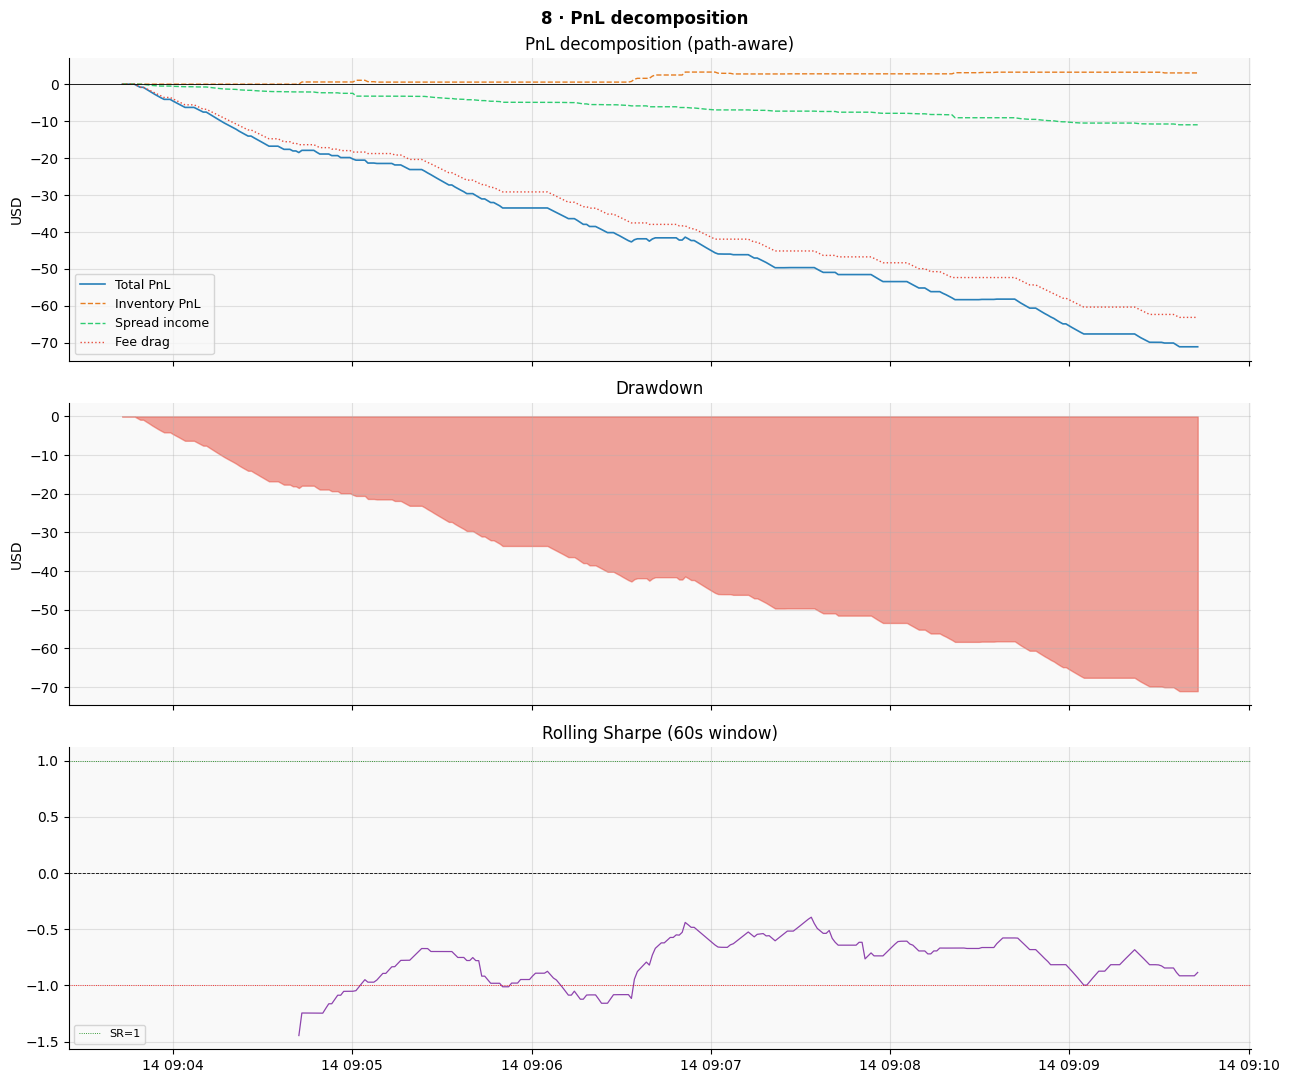

  Spread income : -10.9909
  Inventory PnL : +3.0399
  Fee drag      : -63.0934
  Total         : -71.0443  (check: -71.0443)


In [40]:
mid_arr = df['mid'].values
inv_arr = df['inventory'].values
pnl_arr = df['pnl'].values

# step-by-step inventory PnL: inv[t-1] × (mid[t] − mid[t-1])
inv_pnl_path = np.cumsum(
    np.concatenate([[0], inv_arr[:-1] * np.diff(mid_arr)])
)

# fee path
inv_delta    = np.abs(np.diff(inv_arr, prepend=inv_arr[0]))
fee_per_step = np.where(inv_delta > 1e-9, inv_delta * mid_arr * FEE_BPS, 0.0)
fee_path     = np.cumsum(fee_per_step)

# spread income = residual
spread_path  = pnl_arr - inv_pnl_path + fee_path

# drawdown
peak = np.maximum.accumulate(pnl_arr)
dd   = pnl_arr - peak

# rolling sharpe
roll_ret = pd.Series(pnl_arr).diff().fillna(0)
roll_sr  = roll_ret.rolling(60).mean() / (roll_ret.rolling(60).std() + 1e-12)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# PnL decomposition
ax = axes[0]
ax.plot(df.index, pnl_arr,      label='Total PnL',      linewidth=1.2, color='#2980b9')
ax.plot(df.index, inv_pnl_path, label='Inventory PnL',  linewidth=1.0, color='#e67e22', linestyle='--')
ax.plot(df.index, spread_path,  label='Spread income',  linewidth=1.0, color='#2ecc71', linestyle='--')
ax.plot(df.index, -fee_path,    label='Fee drag',        linewidth=1.0, color='#e74c3c', linestyle=':')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('PnL decomposition (path-aware)')
ax.set_ylabel('USD')
ax.legend(fontsize=9)

# drawdown
ax = axes[1]
ax.fill_between(df.index, dd, 0, color='#e74c3c', alpha=0.5)
ax.set_title('Drawdown')
ax.set_ylabel('USD')

# rolling Sharpe
ax = axes[2]
ax.plot(df.index, roll_sr, color='#8e44ad', linewidth=0.9)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.axhline( 1, color='green', linewidth=0.6, linestyle=':', label='SR=1')
ax.axhline(-1, color='red',   linewidth=0.6, linestyle=':')
ax.set_title('Rolling Sharpe (60s window)')
ax.legend(fontsize=8)

plt.suptitle('8 · PnL decomposition', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'  Spread income : {spread_path[-1]:+.4f}')
print(f'  Inventory PnL : {inv_pnl_path[-1]:+.4f}')
print(f'  Fee drag      : {-fee_path[-1]:+.4f}')
print(f'  Total         : {pnl_arr[-1]:+.4f}  '
      f'(check: {spread_path[-1] + inv_pnl_path[-1] - fee_path[-1]:+.4f})')

# 9 · Regime analysis

Most strategies only work in specific regimes.


=== Regime analysis ===
            rows  sharpe  fill_rate  pnl_delta  inv_std
regime                                                 
Low vol      235 -0.7676     0.2787   -69.2196  0.05114
Mid vol        0     NaN        NaN        NaN      NaN
High vol     116 -0.2047     0.1034   -53.1397  0.04552
Toxic flow   218 -0.3707     0.1560   -71.0443  0.04959
Clean flow   142 -0.7857     0.3169   -71.0443  0.04696


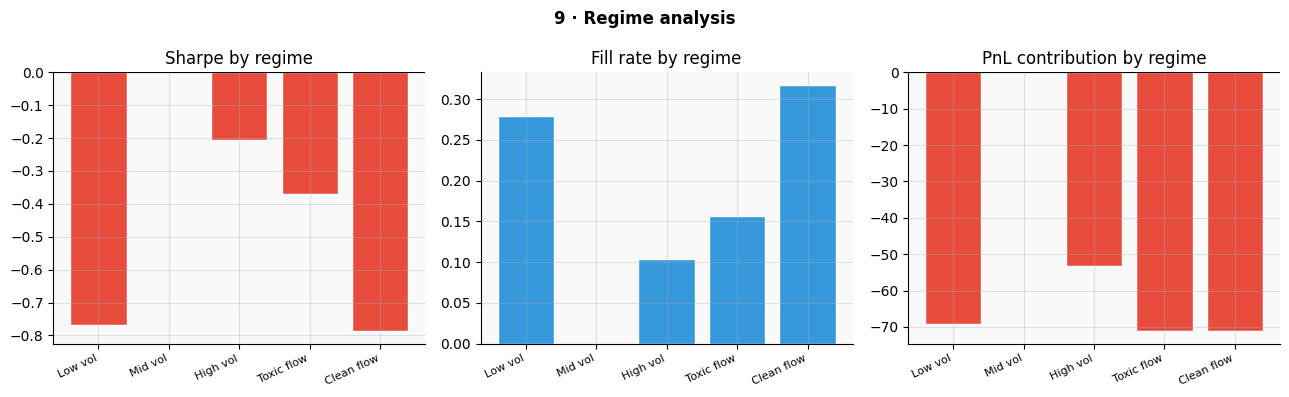

In [41]:
def regime_stats(mask, label):
    sub = df[mask]
    if len(sub) < 5:
        return {'regime': label, 'rows': len(sub)}
    p = sub['pnl'].values
    r = np.diff(p)
    sr = r.mean() / r.std() if r.std() > 0 else 0
    fills_in = sub['fill_mask'].sum()
    ord_in   = len(sub) * 2
    return {
        'regime':    label,
        'rows':      len(sub),
        'sharpe':    round(sr, 4),
        'fill_rate': round(fills_in / ord_in if ord_in else 0, 4),
        'pnl_delta': round(p[-1] - p[0], 4),
        'inv_std':   round(sub['inventory'].std(), 5),
    }

vol_q33  = realized.quantile(0.33)
vol_q67  = realized.quantile(0.67)
tox_mask = df['tfi'].abs() > 0.5

regimes = [
    regime_stats(realized <= vol_q33,                          'Low vol'),
    regime_stats((realized > vol_q33) & (realized <= vol_q67), 'Mid vol'),
    regime_stats(realized > vol_q67,                           'High vol'),
    regime_stats(tox_mask,                                     'Toxic flow'),
    regime_stats(~tox_mask,                                    'Clean flow'),
]

reg_df = pd.DataFrame(regimes).set_index('regime')
print('\n=== Regime analysis ===')
print(reg_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sharpes = reg_df['sharpe'].values
axes[0].bar(reg_df.index, sharpes,
            color=['#2ecc71' if v >= 0 else '#e74c3c' for v in sharpes],
            edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Sharpe by regime')
plt.setp(axes[0].get_xticklabels(), rotation=25, ha='right', fontsize=8)

axes[1].bar(reg_df.index, reg_df['fill_rate'], color='#3498db', edgecolor='white')
axes[1].set_title('Fill rate by regime')
plt.setp(axes[1].get_xticklabels(), rotation=25, ha='right', fontsize=8)

axes[2].bar(reg_df.index, reg_df['pnl_delta'],
            color=['#2ecc71' if v >= 0 else '#e74c3c' for v in reg_df['pnl_delta']],
            edgecolor='white')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('PnL contribution by regime')
plt.setp(axes[2].get_xticklabels(), rotation=25, ha='right', fontsize=8)

plt.suptitle('9 · Regime analysis', fontweight='bold')
plt.tight_layout()
plt.show()

# 10 · Stress tests

Does the strategy collapse under mild realism changes?

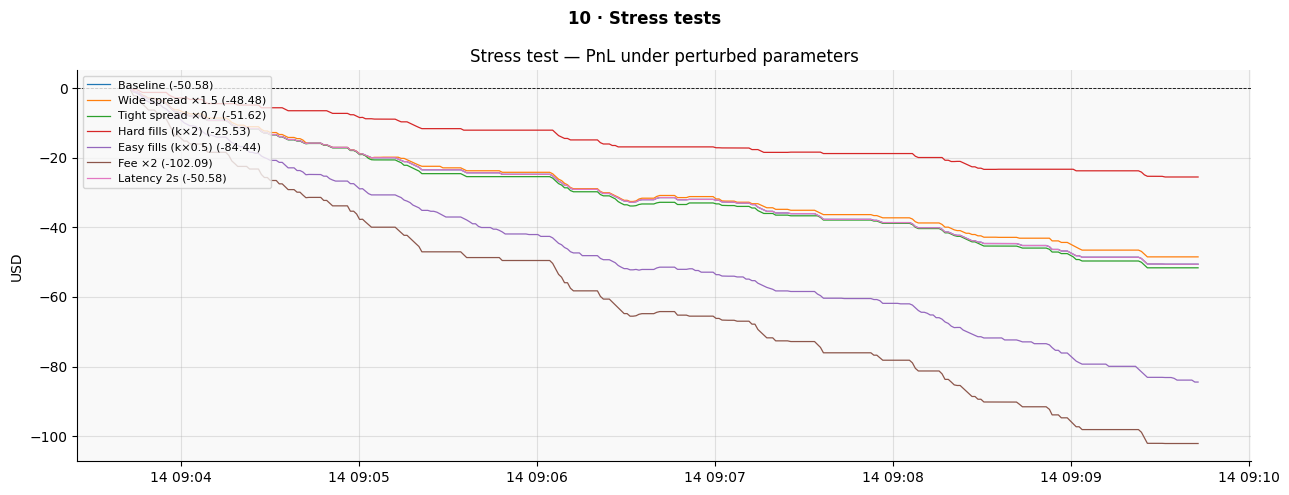


=== Stress test results ===
  Baseline              : PnL=-50.5815  Sharpe=-0.5769
  Wide spread ×1.5      : PnL=-48.4809  Sharpe=-0.5652
  Tight spread ×0.7     : PnL=-51.6224  Sharpe=-0.5682
  Hard fills (k×2)      : PnL=-25.5340  Sharpe=-0.4045
  Easy fills (k×0.5)    : PnL=-84.4382  Sharpe=-0.7801
  Fee ×2                : PnL=-102.0932  Sharpe=-0.5914
  Latency 2s            : PnL=-50.5815  Sharpe=-0.5769


In [42]:
def simulate_pnl(spread_mult=1.0, fill_k_mult=1.0, fee_mult=1.0, latency_rows=0):
    """Re-simulate PnL under perturbed parameters."""
    import math, random as rnd
    rnd.seed(42)
    cash = 0.0
    inv  = 0.0
    k    = FILL_K * fill_k_mult
    fee  = FEE_BPS * fee_mult
    pnls = []
    rows = df.reset_index()

    for i, row in rows.iterrows():
        src_i = max(0, i - latency_rows)
        src   = rows.iloc[src_i]
        mid   = row['mid']
        best_bid = row['bid_0_price']
        best_ask = row['ask_0_price']
        hs    = row['half_spread'] * spread_mult
        bid   = row['fair'] - hs
        ask   = row['fair'] + hs

        for side, price, opp in [('buy', bid, best_ask), ('sell', ask, best_bid)]:
            if abs(inv) >= MAX_INV and side == ('buy' if inv > 0 else 'sell'):
                continue
            dist = abs(price - opp) / max(mid, 1)
            p    = math.exp(-k * dist)
            if rnd.random() < p:
                notional = QUOTE_SZ * price
                f = notional * fee
                if side == 'buy':
                    cash -= notional + f
                    inv  += QUOTE_SZ
                else:
                    cash += notional - f
                    inv  -= QUOTE_SZ
        pnls.append(cash + inv * mid)
    return np.array(pnls)

scenarios = {
    'Baseline':          dict(),
    'Wide spread ×1.5':  dict(spread_mult=1.5),
    'Tight spread ×0.7': dict(spread_mult=0.7),
    'Hard fills (k×2)':  dict(fill_k_mult=2.0),
    'Easy fills (k×0.5)':dict(fill_k_mult=0.5),
    'Fee ×2':            dict(fee_mult=2.0),
    'Latency 2s':        dict(latency_rows=2),
}

fig, ax = plt.subplots(figsize=(13, 5))
results = {}
for label, kwargs in scenarios.items():
    p = simulate_pnl(**kwargs)
    r = np.diff(p)
    sr = r.mean() / r.std() if r.std() > 0 else 0
    results[label] = {'final_pnl': p[-1], 'sharpe': sr}
    ax.plot(df.index, p, label=f'{label} ({p[-1]:+.2f})', linewidth=0.9)

ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('Stress test — PnL under perturbed parameters')
ax.set_ylabel('USD')
ax.legend(fontsize=8, loc='upper left')
plt.suptitle('10 · Stress tests', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Stress test results ===')
for label, r in results.items():
    print(f'  {label:<22}: PnL={r["final_pnl"]:+.4f}  Sharpe={r["sharpe"]:+.4f}')

# 11 · Summary table

In [43]:
def sharpe(p): r=np.diff(p); return r.mean()/r.std() if len(r)>1 and r.std()>0 else 0
def sortino(p):
    r=np.diff(p); d=r[r<0]
    return r.mean()/d.std() if len(d)>1 and d.std()>0 else 0
def max_dd(p):
    pk=np.maximum.accumulate(p); return float((p-pk).min())
def profit_factor(p):
    r=np.diff(p); g,l=r[r>0].sum(),abs(r[r<0].sum())
    return g/l if l>0 else 0

mo5_mean = np.mean(markout_results.get('5s', [0])) if markout_results.get('5s', []) is not None else 0
uptime   = float((df['fill_mask'] | (df['inventory'].abs() < MAX_INV)).mean())

summary = [
    ('Session duration',    f'{duration_s/60:.1f} min'),
    ('Rows',                len(df)),
    ('--- Performance',     '---'),
    ('Final PnL',           f'{pnl_arr[-1]:+.4f}'),
    ('Sharpe',              f'{sharpe(pnl_arr):.4f}'),
    ('Sortino',             f'{sortino(pnl_arr):.4f}'),
    ('Max Drawdown',        f'{max_dd(pnl_arr):.4f}'),
    ('Profit Factor',       f'{profit_factor(pnl_arr):.4f}'),
    ('--- Market Making',   '---'),
    ('Fill Rate',           f'{n_fills/n_orders:.4f}'),
    ('Inv Turnover (BTC)',  f'{np.abs(np.diff(inv_arr)).sum():.4f}'),
    ('Zero Crossings',      sign_changes),
    ('Time at Max Inv',     f'{time_at_max:.1%}'),
    ('Avg Markout (5s)',    f'{mo5_mean:+.4f}'),
    ('Quote Uptime',        f'{uptime:.1%}'),
    ('Inv Volatility',      f'{inv_std:.5f}'),
    ('--- Decomposition',   '---'),
    ('Spread Income',       f'{spread_path[-1]:+.4f}'),
    ('Inventory PnL',       f'{inv_pnl_path[-1]:+.4f}'),
    ('Fee Drag',            f'{-fee_path[-1]:+.4f}'),
]

print('\n' + '='*46)
print('  BTC/USDT MARKET MAKER — FULL SUMMARY')
print('='*46)
for k, v in summary:
    if str(v) == '---':
        print(f'  {k}')
    else:
        print(f'    {k:<24}: {v}')
print('='*46)


  BTC/USDT MARKET MAKER — FULL SUMMARY
    Session duration        : 6.0 min
    Rows                    : 360
  --- Performance
    Final PnL               : -71.0443
    Sharpe                  : -0.7960
    Sortino                 : -2.2472
    Max Drawdown            : -71.0443
    Profit Factor           : 0.0445
  --- Market Making
    Fill Rate               : 0.2194
    Inv Turnover (BTC)      : 0.7900
    Zero Crossings          : 0
    Time at Max Inv         : 1.7%
    Avg Markout (5s)        : -9.1439
    Quote Uptime            : 98.9%
    Inv Volatility          : 0.04872
  --- Decomposition
    Spread Income           : -10.9909
    Inventory PnL           : +3.0399
    Fee Drag                : -63.0934
